# Sentiment Analysis Visualization Dashboard

This notebook provides comprehensive visualizations of the sentiment analysis results from the Chinese LLM research project.

**Dataset**: Weibo posts about filial piety (孝道)  
**Source**: `results/qwen_analysis_results.csv`  
**English Bucket Names**: Daily Practice, Obligation, Family Conflict, Theory/Critique, Marriage/Dating

In [2]:
# Import Required Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import os

# Set style for better looking plots with English text
plt.style.use('default')
sns.set_palette("husl")
# Ensure matplotlib can handle any font issues
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## Data Loading and Preparation

Load the analysis results and normalize bucket names from Chinese to English for matplotlib compatibility.

**Bucket Mapping**:
- 日常实践 → Daily Practice
- 责任义务 → Obligation
- 家庭冲突 → Family Conflict
- 理论探讨 → Theory/Critique
- 婚恋择偶 → Marriage/Dating

In [3]:
def normalize_bucket_names(df):
    """Normalize bucket names to English for matplotlib compatibility"""
    
    df = df.copy()
    
    # Create mapping: Chinese → English
    bucket_mapping = {
        # Chinese to English
        '日常实践': 'Daily Practice',
        '责任义务': 'Obligation', 
        '家庭冲突': 'Family Conflict',
        '理论探讨': 'Theory/Critique',
        '婚恋择偶': 'Marriage/Dating',
        # Mixed formats (old data)
        'Care(赡养照护)': 'Daily Practice',
        'Obligation(责任义务)': 'Obligation', 
        'Conflict(家庭冲突)': 'Family Conflict',
        'Critique/Abstract(理论探讨)': 'Theory/Critique',
        'Reciprocity(情感互惠)': 'Daily Practice',
        # Pure English (already correct or legacy)
        'Care': 'Daily Practice',
        'Reciprocity': 'Daily Practice',
        'Conflict': 'Family Conflict',
        'Critique/Abstract': 'Theory/Critique',
        # Handle None/empty
        'None': '',
        'none': '',
        'nan': '',
    }
    
    # Apply normalization
    df['qwen_bucket'] = df['qwen_bucket'].replace(bucket_mapping)
    
    # Remove any remaining whitespace and handle NaN
    df['qwen_bucket'] = df['qwen_bucket'].fillna('').astype(str).str.strip()
    
    return df

def load_and_prepare_data():
    """Load and prepare the analysis results"""
    
    results_file = 'results/qwen_analysis_results.csv'
    
    if not os.path.exists(results_file):
        print(f"ERROR: Results file '{results_file}' not found!")
        print("Run batch_analyze.py first to generate results.")
        return None
    
    print(f"Loading results from: {results_file}")
    df = pd.read_csv(results_file)
    
    # Filter to only processed posts (have sentiment analysis)
    processed_df = df[df['qwen_processed_at'].notna()].copy()
    
    # Normalize bucket names
    print(f"\nBucket normalization:")
    if 'qwen_bucket' in processed_df.columns:
        original_buckets = processed_df['qwen_bucket'].value_counts()
        processed_df = normalize_bucket_names(processed_df)
        normalized_buckets = processed_df['qwen_bucket'].value_counts()
        
        print(f"Original unique buckets: {len(original_buckets)}")
        print(f"Normalized unique buckets: {len(normalized_buckets)}")
    
    print(f"\nTotal posts in file: {len(df):,}")
    print(f"Successfully processed: {len(processed_df):,}")
    
    # Show error breakdown if any
    if 'qwen_error' in processed_df.columns:
        errors = processed_df['qwen_error'].notna().sum()
        if errors > 0:
            print(f"Posts with errors: {errors:,}")
            error_breakdown = processed_df[processed_df['qwen_error'].notna()]['qwen_error'].value_counts()
            print("\nError types:")
            for error_type, count in error_breakdown.items():
                print(f"  {error_type}: {count}")
    
    if len(processed_df) == 0:
        print("No processed posts found!")
        return None
    
    return processed_df

# Load the data
df = load_and_prepare_data()

if df is not None:
    print(f"\n✓ Data loaded successfully: {len(df):,} posts")

Loading results from: results/qwen_analysis_results.csv

Bucket normalization:
Original unique buckets: 5
Normalized unique buckets: 6

Total posts in file: 31,857
Successfully processed: 31,857
Posts with errors: 3

Error types:
  json_extraction_failed: 3

✓ Data loaded successfully: 31,857 posts


## 1. Sentiment Distribution (Bar Chart)

Visualize how posts are distributed across sentiment scores from -2 (strongly negative) to +2 (strongly positive).

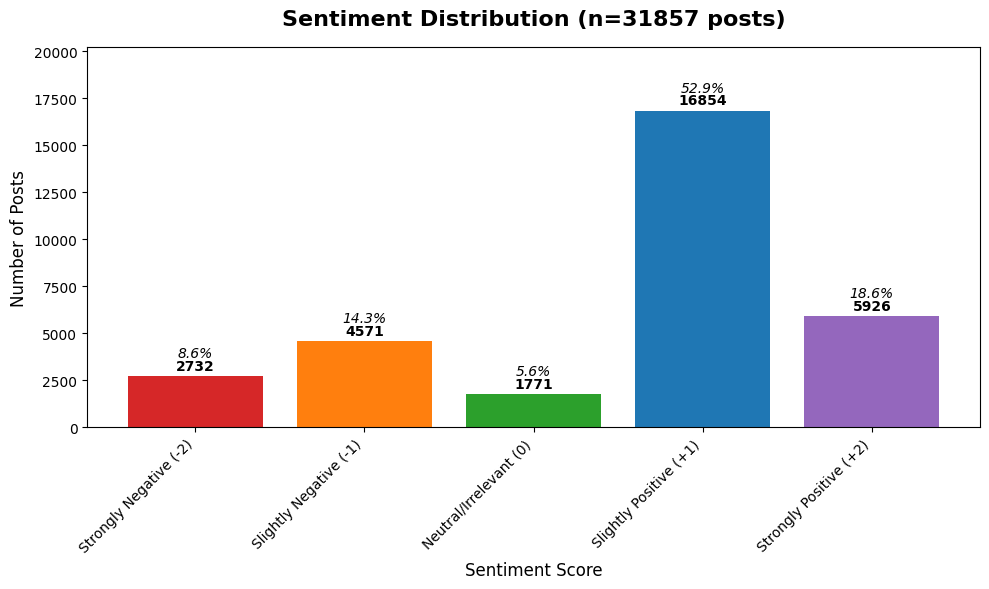


✓ Sentiment distribution chart created

Sentiment Counts:
  Strongly Negative (-2): 2,732 (8.6%)
  Slightly Negative (-1): 4,571 (14.3%)
  Neutral/Irrelevant (0): 1,771 (5.6%)
  Slightly Positive (+1): 16,854 (52.9%)
  Strongly Positive (+2): 5,926 (18.6%)


In [4]:
if df is not None:
    plt.figure(figsize=(10, 6))
    
    # Count sentiment scores
    sentiment_counts = df['qwen_sentiment'].value_counts().sort_index()
    
    # Create labels with descriptions
    sentiment_labels = {
        -2: 'Strongly Negative (-2)',
        -1: 'Slightly Negative (-1)', 
        0: 'Neutral/Irrelevant (0)',
        1: 'Slightly Positive (+1)',
        2: 'Strongly Positive (+2)'
    }
    
    # Plot bar chart
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, 
                   color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4', '#9467bd'])
    
    plt.title(f'Sentiment Distribution (n={len(df)} posts)', fontsize=16, fontweight='bold', pad=16)
    plt.xlabel('Sentiment Score', fontsize=12)
    plt.ylabel('Number of Posts', fontsize=12)
    
    # Add headroom so percentage labels do not overlap with title
    max_count = sentiment_counts.values.max()
    plt.ylim(0, max_count * 1.20)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max_count * 0.01,
                f'{int(height)}',
                ha='center', va='bottom', fontweight='bold')
    
    # Add percentage labels
    total = len(df)
    for score, count in sentiment_counts.items():
        percentage = (count / total) * 100
        plt.text(score, count + max_count * 0.05,
                f'{percentage:.1f}%',
                ha='center', va='bottom', fontsize=10, style='italic')
    
    plt.xticks(list(sentiment_labels.keys()), 
               [sentiment_labels[k] for k in sorted(sentiment_labels.keys())])
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Save plot
    os.makedirs('results', exist_ok=True)
    plt.savefig('results/sentiment_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Sentiment distribution chart created")
    print("\nSentiment Counts:")
    for score, count in sentiment_counts.items():
        percentage = (count / total) * 100
        print(f"  {sentiment_labels[score]}: {count:,} ({percentage:.1f}%)")

## 1.1 Temporal Sentiment Distribution by Year

Track how sentiment composition changes over time using yearly stacked percentages.

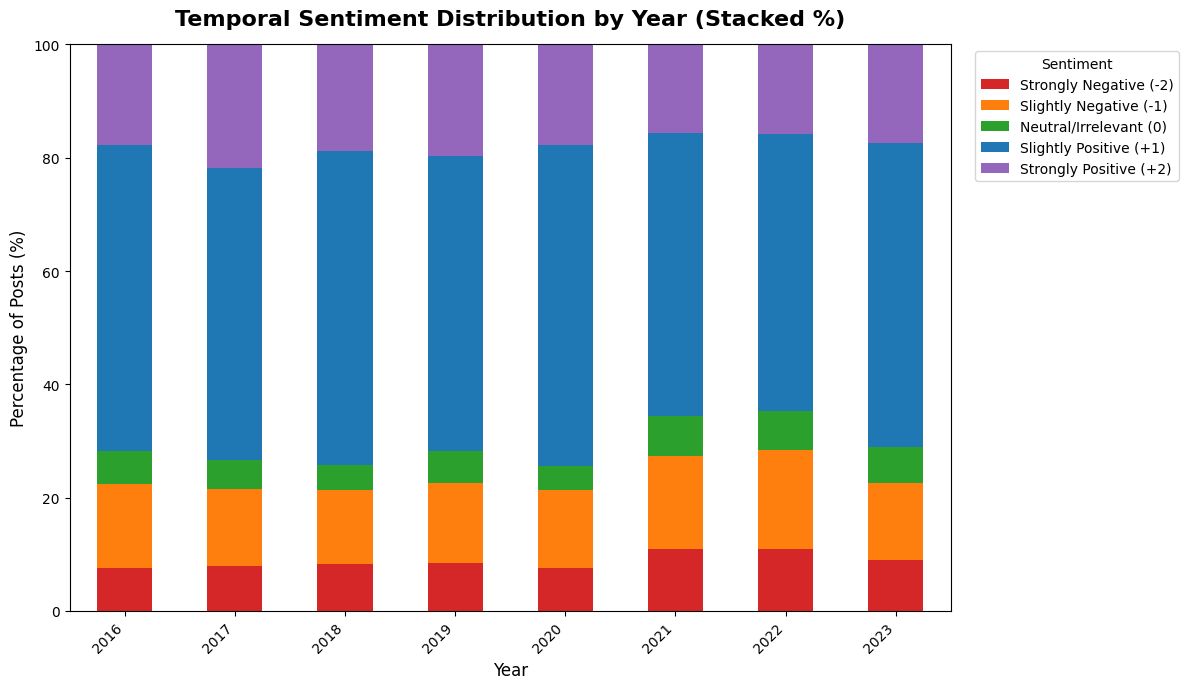


✓ Temporal sentiment distribution by year chart created
Date column used: time

Posts by year:
  2016: 5,863 posts
  2017: 5,954 posts
  2018: 4,990 posts
  2019: 4,631 posts
  2020: 2,506 posts
  2021: 2,545 posts
  2022: 2,594 posts
  2023: 2,771 posts


In [5]:
if df is not None:
    # Identify datetime column for temporal analysis
    date_col_candidates = ['time', 'created_at', 'date', 'timestamp']
    date_col = next((c for c in date_col_candidates if c in df.columns), None)
    
    if date_col is None:
        print("\n⚠ No datetime column found for temporal sentiment analysis.")
        print(f"Checked columns: {date_col_candidates}")
    else:
        temporal_df = df.copy()
        temporal_df['qwen_sentiment'] = pd.to_numeric(temporal_df['qwen_sentiment'], errors='coerce')
        temporal_df = temporal_df[temporal_df['qwen_sentiment'].isin([-2, -1, 0, 1, 2])].copy()
        temporal_df['year'] = pd.to_datetime(temporal_df[date_col], errors='coerce').dt.year
        temporal_df = temporal_df.dropna(subset=['year'])
        temporal_df['year'] = temporal_df['year'].astype(int)
        
        if temporal_df.empty:
            print("\n⚠ No valid temporal data available after parsing dates.")
        else:
            # Count by year and sentiment, then convert to percentages
            yearly_counts = temporal_df.groupby(['year', 'qwen_sentiment']).size().unstack(fill_value=0)
            yearly_counts = yearly_counts.reindex(columns=[-2, -1, 0, 1, 2], fill_value=0).sort_index()
            yearly_pct = yearly_counts.div(yearly_counts.sum(axis=1), axis=0) * 100
            
            sentiment_labels = {
                -2: 'Strongly Negative (-2)',
                -1: 'Slightly Negative (-1)',
                0: 'Neutral/Irrelevant (0)',
                1: 'Slightly Positive (+1)',
                2: 'Strongly Positive (+2)'
            }
            sentiment_colors = {
                -2: '#d62728',
                -1: '#ff7f0e',
                0: '#2ca02c',
                1: '#1f77b4',
                2: '#9467bd'
            }
            
            ax = yearly_pct.plot(
                kind='bar',
                stacked=True,
                figsize=(12, 7),
                color=[sentiment_colors[s] for s in yearly_pct.columns]
            )
            
            plt.title('Temporal Sentiment Distribution by Year (Stacked %)', fontsize=16, fontweight='bold', pad=14)
            plt.xlabel('Year', fontsize=12)
            plt.ylabel('Percentage of Posts (%)', fontsize=12)
            plt.ylim(0, 100)
            plt.legend(
                [sentiment_labels[s] for s in yearly_pct.columns],
                title='Sentiment',
                bbox_to_anchor=(1.02, 1),
                loc='upper left'
            )
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            
            # Save plot
            os.makedirs('results', exist_ok=True)
            plt.savefig('results/temporal_sentiment_distribution_by_year.png', dpi=300, bbox_inches='tight')
            plt.show()
            
            print("\n✓ Temporal sentiment distribution by year chart created")
            print(f"Date column used: {date_col}")
            print("\nPosts by year:")
            yearly_totals = yearly_counts.sum(axis=1)
            for year, count in yearly_totals.items():
                print(f"  {year}: {count:,} posts")

## 2. Context Bucket Distribution (Bar + Pie Charts)

Show how non-neutral posts are distributed across different context buckets (Daily Practice, Obligation, Family Conflict, Theory/Critique, Marriage/Dating).

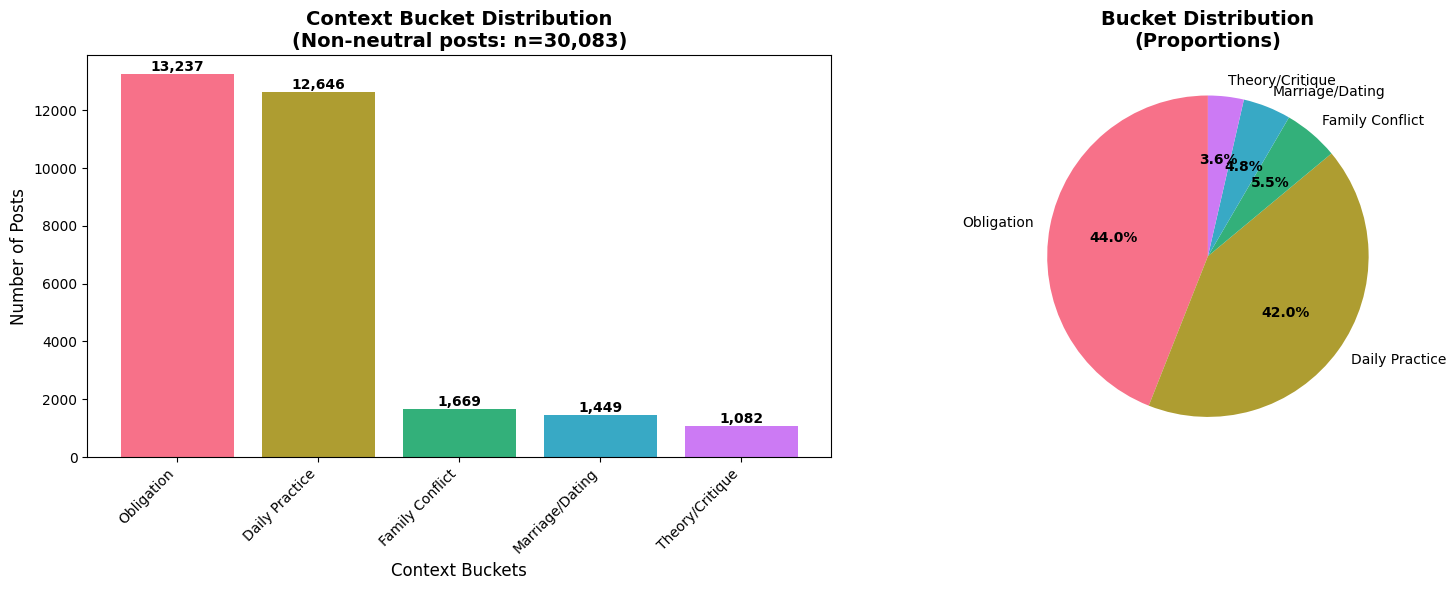


✓ Bucket distribution charts created

Bucket Counts:
  Obligation: 13,237 (44.0%)
  Daily Practice: 12,646 (42.0%)
  Family Conflict: 1,669 (5.5%)
  Marriage/Dating: 1,449 (4.8%)
  Theory/Critique: 1,082 (3.6%)


In [5]:
if df is not None:
    # Only look at posts with non-zero sentiment and valid buckets
    relevant_df = df[(df['qwen_sentiment'] != 0) & (df['qwen_bucket'].notna()) & (df['qwen_bucket'] != '')].copy()
    
    if len(relevant_df) > 0:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Bucket counts
        bucket_counts = relevant_df['qwen_bucket'].value_counts()
        
        # Bar chart
        bars = ax1.bar(range(len(bucket_counts)), bucket_counts.values, 
                       color=sns.color_palette("husl", len(bucket_counts)))
        ax1.set_title(f'Context Bucket Distribution\n(Non-neutral posts: n={len(relevant_df):,})', 
                      fontsize=14, fontweight='bold')
        ax1.set_xlabel('Context Buckets', fontsize=12)
        ax1.set_ylabel('Number of Posts', fontsize=12)
        ax1.set_xticks(range(len(bucket_counts)))
        ax1.set_xticklabels(bucket_counts.index, rotation=45, ha='right')
        
        # Add value labels
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold')
        
        # Pie chart
        colors = sns.color_palette("husl", len(bucket_counts))
        wedges, texts, autotexts = ax2.pie(bucket_counts.values, labels=bucket_counts.index, 
                                          autopct='%1.1f%%', startangle=90, colors=colors)
        ax2.set_title('Bucket Distribution\n(Proportions)', fontsize=14, fontweight='bold')
        
        # Make percentage text bold
        for autotext in autotexts:
            autotext.set_fontweight('bold')
        
        plt.tight_layout()
        plt.savefig('results/bucket_distribution.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Bucket distribution charts created")
        print("\nBucket Counts:")
        for bucket, count in bucket_counts.items():
            percentage = (count / len(relevant_df)) * 100
            print(f"  {bucket}: {count:,} ({percentage:.1f}%)")
    else:
        print("No posts with bucket classifications found")

## 3. Confidence Score Analysis (4-Panel Visualization)

Comprehensive analysis of model confidence scores:
1. **Histogram**: Overall distribution of confidence scores
2. **Scatter Plot**: Confidence vs. sentiment relationship
3. **Bar Chart**: Average confidence by context bucket
4. **Low Confidence Posts**: Breakdown by sentiment for posts needing review

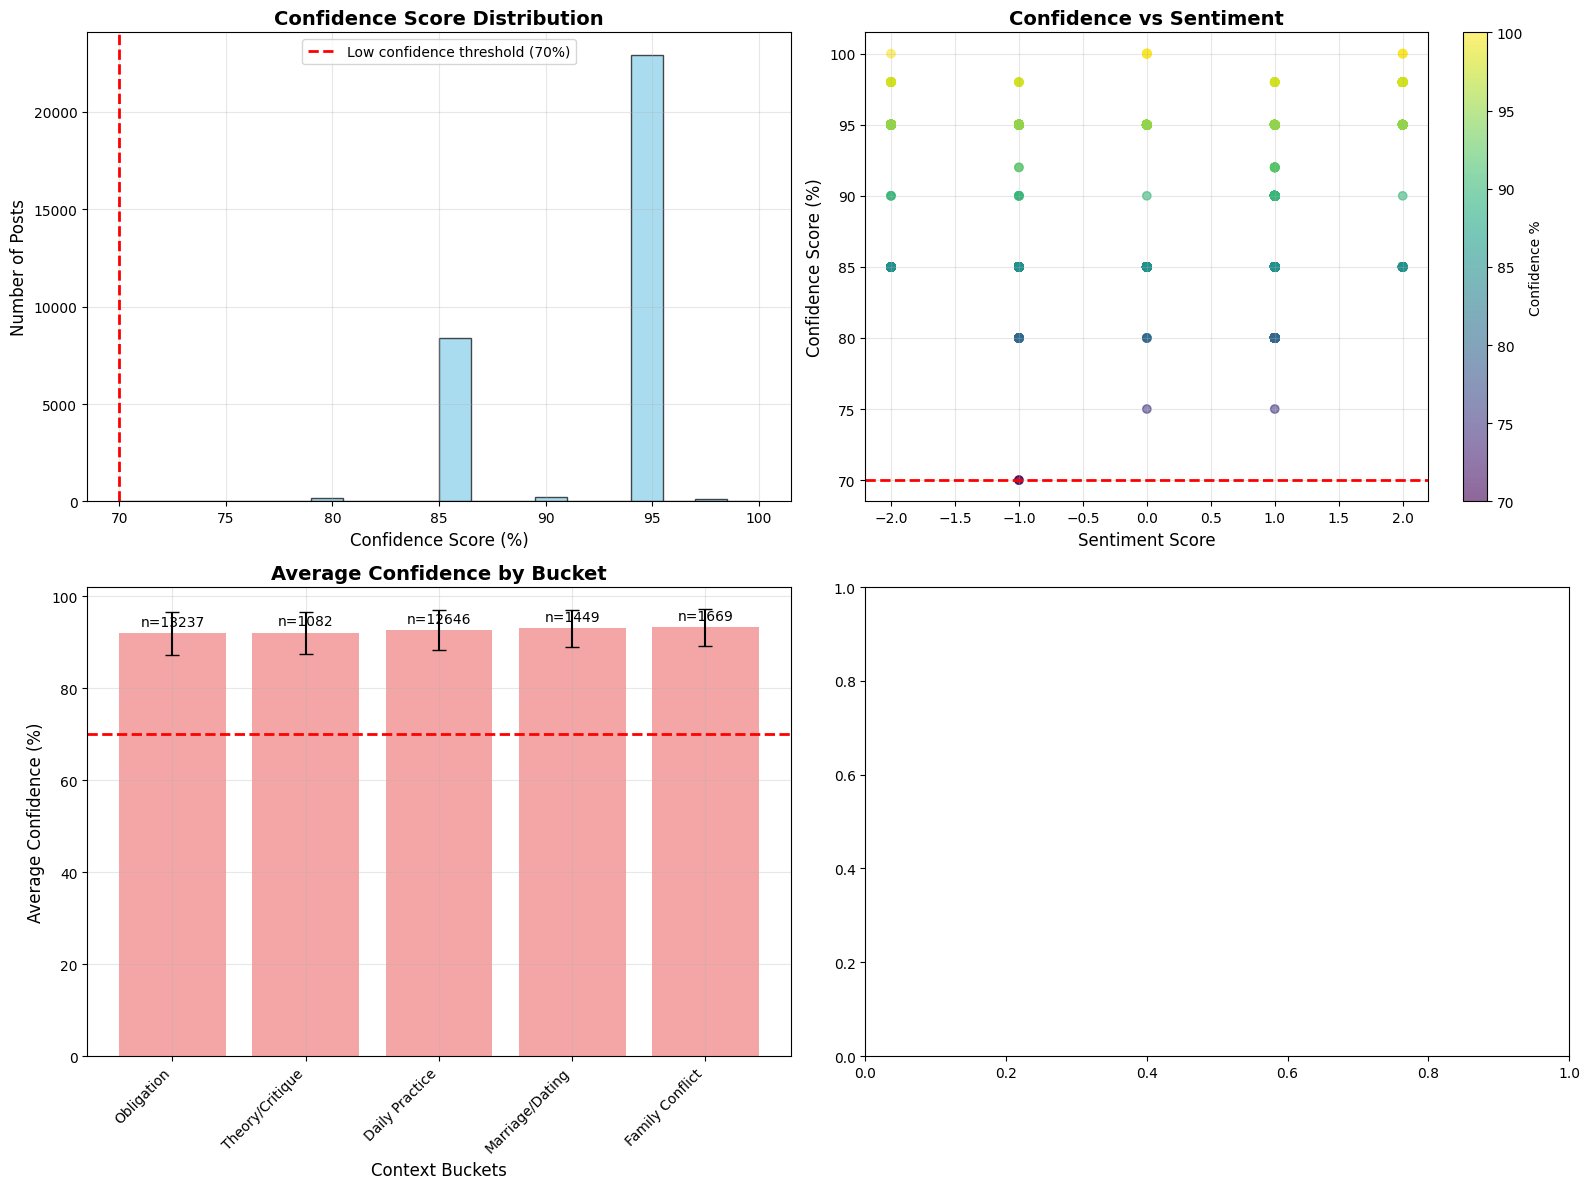


✓ Confidence analysis created

Confidence Statistics:
  Average: 92.3%
  Median: 95.0%
  Range: 70.0% - 100.0%
  Posts < 70%: 0 (0.0%)


In [6]:
if df is not None:
    low_confidence_threshold = 70
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Confidence distribution histogram
    ax1.hist(df['qwen_confidence'], bins=20, edgecolor='black', alpha=0.7, color='skyblue')
    ax1.axvline(low_confidence_threshold, color='red', linestyle='--', linewidth=2, 
                label=f'Low confidence threshold ({low_confidence_threshold}%)')
    ax1.set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Confidence Score (%)', fontsize=12)
    ax1.set_ylabel('Number of Posts', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Confidence vs Sentiment scatter
    scatter = ax2.scatter(df['qwen_sentiment'], df['qwen_confidence'], 
                         alpha=0.6, c=df['qwen_confidence'], cmap='viridis')
    ax2.axhline(low_confidence_threshold, color='red', linestyle='--', linewidth=2)
    ax2.set_title('Confidence vs Sentiment', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Sentiment Score', fontsize=12)
    ax2.set_ylabel('Confidence Score (%)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax2, label='Confidence %')
    
    # 3. Confidence by bucket (for posts with buckets)
    relevant_df = df[(df['qwen_sentiment'] != 0) & (df['qwen_bucket'].notna()) & (df['qwen_bucket'] != '')]
    if len(relevant_df) > 0:
        bucket_confidence = relevant_df.groupby('qwen_bucket')['qwen_confidence'].agg(['mean', 'std', 'count'])
        bucket_confidence = bucket_confidence.sort_values('mean')
        
        bars = ax3.bar(range(len(bucket_confidence)), bucket_confidence['mean'], 
                      yerr=bucket_confidence['std'], capsize=5, alpha=0.7, color='lightcoral')
        ax3.axhline(low_confidence_threshold, color='red', linestyle='--', linewidth=2)
        ax3.set_title('Average Confidence by Bucket', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Context Buckets', fontsize=12)
        ax3.set_ylabel('Average Confidence (%)', fontsize=12)
        ax3.set_xticks(range(len(bucket_confidence)))
        ax3.set_xticklabels(bucket_confidence.index, rotation=45, ha='right')
        ax3.grid(True, alpha=0.3)
        
        # Add count labels
        for i, (bar, count) in enumerate(zip(bars, bucket_confidence['count'])):
            ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                    f'n={count}',
                    ha='center', va='bottom', fontsize=10)
    
    # 4. Low confidence posts by sentiment
    low_conf_df = df[df['qwen_confidence'] < low_confidence_threshold]
    if len(low_conf_df) > 0:
        low_conf_sentiment = low_conf_df['qwen_sentiment'].value_counts().sort_index()
        ax4.bar(low_conf_sentiment.index, low_conf_sentiment.values, 
               color='orange', alpha=0.7)
        ax4.set_title(f'Low Confidence Posts by Sentiment\n(n={len(low_conf_df)} posts need review)', 
                     fontsize=14, fontweight='bold')
        ax4.set_xlabel('Sentiment Score', fontsize=12)
        ax4.set_ylabel('Number of Low Confidence Posts', fontsize=12)
        ax4.grid(True, alpha=0.3)
        
        # Add value labels
        for i, (score, count) in enumerate(low_conf_sentiment.items()):
            ax4.text(score, count, f'{count}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('results/confidence_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Confidence analysis created")
    print(f"\nConfidence Statistics:")
    print(f"  Average: {df['qwen_confidence'].mean():.1f}%")
    print(f"  Median: {df['qwen_confidence'].median():.1f}%")
    print(f"  Range: {df['qwen_confidence'].min():.1f}% - {df['qwen_confidence'].max():.1f}%")
    print(f"  Posts < {low_confidence_threshold}%: {len(low_conf_df):,} ({len(low_conf_df)/len(df)*100:.1f}%)")

## 4. Sentiment-Bucket Heatmap

Cross-tabulation showing how sentiment scores are distributed across different context buckets. This reveals which topics tend to have more positive or negative sentiment.

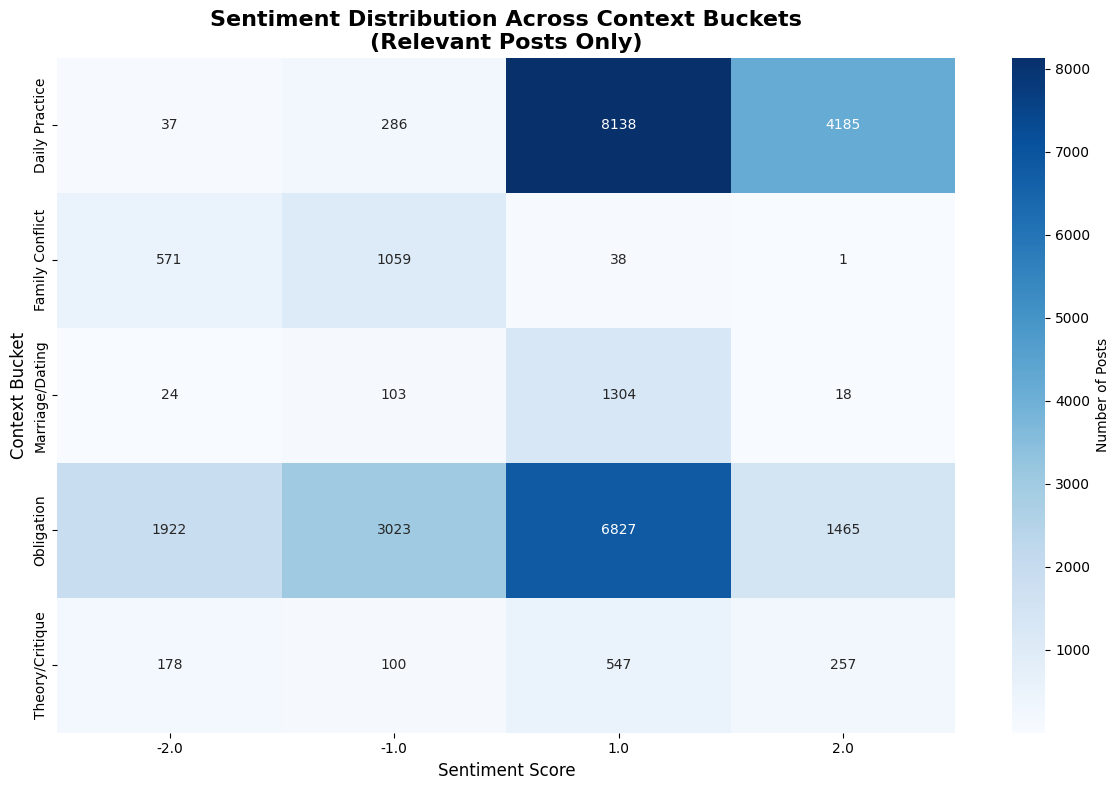


✓ Sentiment-bucket heatmap created

Crosstab with Totals:
qwen_sentiment   -2.0  -1.0    1.0   2.0    All
qwen_bucket                                    
Daily Practice     37   286   8138  4185  12646
Family Conflict   571  1059     38     1   1669
Marriage/Dating    24   103   1304    18   1449
Obligation       1922  3023   6827  1465  13237
Theory/Critique   178   100    547   257   1082
All              2732  4571  16854  5926  30083


In [7]:
if df is not None:
    relevant_df = df[(df['qwen_sentiment'] != 0) & (df['qwen_bucket'].notna()) & (df['qwen_bucket'] != '')]
    
    if len(relevant_df) > 0:
        # Create crosstab
        sentiment_bucket_crosstab = pd.crosstab(relevant_df['qwen_bucket'], 
                                               relevant_df['qwen_sentiment'], 
                                               margins=True)
        
        # Remove margins for heatmap, keep for reference
        heatmap_data = sentiment_bucket_crosstab.iloc[:-1, :-1]  # Remove 'All' row and column
        
        plt.figure(figsize=(12, 8))
        sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues', 
                    cbar_kws={'label': 'Number of Posts'})
        plt.title('Sentiment Distribution Across Context Buckets\n(Relevant Posts Only)', 
                  fontsize=16, fontweight='bold')
        plt.xlabel('Sentiment Score', fontsize=12)
        plt.ylabel('Context Bucket', fontsize=12)
        
        plt.tight_layout()
        plt.savefig('results/sentiment_bucket_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print("\n✓ Sentiment-bucket heatmap created")
        print("\nCrosstab with Totals:")
        print(sentiment_bucket_crosstab)
    else:
        print("No posts with bucket classifications for heatmap")

## 5. Export Low Confidence Posts

Export posts with confidence scores below 70% for manual review and annotation.

In [8]:
if df is not None:
    low_confidence_threshold = 70
    low_conf_df = df[df['qwen_confidence'] < low_confidence_threshold].copy()
    
    if len(low_conf_df) > 0:
        # Select relevant columns for manual review
        review_cols = ['post_id', 'text', 'qwen_sentiment', 
                       'qwen_bucket', 'qwen_confidence', 'qwen_error']
        # Only include columns that exist
        review_cols = [col for col in review_cols if col in low_conf_df.columns]
        
        review_df = low_conf_df[review_cols].copy()
        review_df = review_df.sort_values('qwen_confidence')  # Sort by lowest confidence first
        
        # Add manual review columns
        review_df['manual_relevant'] = ''
        review_df['manual_sentiment'] = ''  
        review_df['manual_bucket'] = ''
        review_df['manual_notes'] = ''
        
        # Export to CSV
        output_file = 'results/low_confidence_posts_for_review.csv'
        review_df.to_csv(output_file, index=False)
        
        print(f"\n✓ Low confidence posts exported")
        print(f"  File: {output_file}")
        print(f"  Posts needing review: {len(review_df):,}")
        print(f"  Confidence range: {review_df['qwen_confidence'].min():.1f}% - {review_df['qwen_confidence'].max():.1f}%")
        
        # Show preview of lowest confidence posts
        print("\nPreview of lowest confidence posts:")
        display(review_df[['post_id', 'text', 'qwen_sentiment', 'qwen_bucket', 'qwen_confidence']].head(5))
    else:
        print(f"No posts found with confidence < {low_confidence_threshold}%")

No posts found with confidence < 70%


## 6. Comprehensive Summary Report

Generate a text summary report with all key statistics and findings.

In [9]:
if df is not None:
    total_posts = len(df)
    # Count posts with buckets (non-neutral sentiment posts)
    relevant_posts = len(df[(df['qwen_sentiment'] != 0) & (df['qwen_bucket'].notna()) & (df['qwen_bucket'] != '')])
    
    report = f"""
SENTIMENT ANALYSIS SUMMARY REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
{'='*50}

DATASET OVERVIEW:
- Total posts analyzed: {total_posts:,}
- Posts with context buckets (non-neutral): {relevant_posts:,} ({relevant_posts/total_posts*100:.1f}%)
- Neutral/irrelevant posts: {total_posts-relevant_posts:,} ({(total_posts-relevant_posts)/total_posts*100:.1f}%)

SENTIMENT DISTRIBUTION:
"""
    
    sentiment_counts = df['qwen_sentiment'].value_counts().sort_index()
    sentiment_labels = {
        -2: 'Strongly Negative', -1: 'Slightly Negative', 0: 'Neutral/Irrelevant',
        1: 'Slightly Positive', 2: 'Strongly Positive'
    }
    
    for score, count in sentiment_counts.items():
        percentage = (count / total_posts) * 100
        label = sentiment_labels.get(score, f'Score {score}')
        report += f"- {label} ({score}): {count:,} posts ({percentage:.1f}%)\n"
    
    if relevant_posts > 0:
        report += f"\nCONTEXT BUCKET DISTRIBUTION (Non-neutral posts only):\n"
        bucket_counts = df[(df['qwen_sentiment'] != 0) & (df['qwen_bucket'].notna()) & (df['qwen_bucket'] != '')]['qwen_bucket'].value_counts()
        for bucket, count in bucket_counts.items():
            percentage = (count / relevant_posts) * 100
            report += f"- {bucket}: {count:,} posts ({percentage:.1f}%)\n"
    
    # Confidence analysis
    report += f"\nCONFIDENCE ANALYSIS:\n"
    report += f"- Average confidence: {df['qwen_confidence'].mean():.1f}%\n"
    report += f"- Median confidence: {df['qwen_confidence'].median():.1f}%\n"
    report += f"- Min confidence: {df['qwen_confidence'].min():.1f}%\n"
    report += f"- Max confidence: {df['qwen_confidence'].max():.1f}%\n"
    
    low_conf_count = len(df[df['qwen_confidence'] < 70])
    report += f"- Posts with confidence < 70%: {low_conf_count:,} ({low_conf_count/total_posts*100:.1f}%)\n"
    
    # Save report
    with open('results/analysis_summary_report.txt', 'w', encoding='utf-8') as f:
        f.write(report)
    
    print(report)
    print("\n✓ Summary report saved to: results/analysis_summary_report.txt")


SENTIMENT ANALYSIS SUMMARY REPORT
Generated: 2026-02-19 22:31:58

DATASET OVERVIEW:
- Total posts analyzed: 31,857
- Posts with context buckets (non-neutral): 30,083 (94.4%)
- Neutral/irrelevant posts: 1,774 (5.6%)

SENTIMENT DISTRIBUTION:
- Strongly Negative (-2.0): 2,732 posts (8.6%)
- Slightly Negative (-1.0): 4,571 posts (14.3%)
- Neutral/Irrelevant (0.0): 1,771 posts (5.6%)
- Slightly Positive (1.0): 16,854 posts (52.9%)
- Strongly Positive (2.0): 5,926 posts (18.6%)

CONTEXT BUCKET DISTRIBUTION (Non-neutral posts only):
- Obligation: 13,237 posts (44.0%)
- Daily Practice: 12,646 posts (42.0%)
- Family Conflict: 1,669 posts (5.5%)
- Marriage/Dating: 1,449 posts (4.8%)
- Theory/Critique: 1,082 posts (3.6%)

CONFIDENCE ANALYSIS:
- Average confidence: 92.3%
- Median confidence: 95.0%
- Min confidence: 70.0%
- Max confidence: 100.0%
- Posts with confidence < 70%: 0 (0.0%)


✓ Summary report saved to: results/analysis_summary_report.txt


## Summary

All visualizations and exports have been generated and saved to the `results/` directory:

**Visualizations**:
1. `sentiment_distribution.png` - Bar chart of sentiment scores
2. `bucket_distribution.png` - Bar + pie charts of context buckets
3. `confidence_analysis.png` - 4-panel confidence analysis
4. `sentiment_bucket_heatmap.png` - Sentiment × bucket crosstab

**Data Exports**:
5. `low_confidence_posts_for_review.csv` - Posts needing manual review
6. `analysis_summary_report.txt` - Comprehensive text summary

**Next Steps**:
- Review low confidence posts manually
- Run `retry_failed_posts.py` to improve success rate
- Use cascade filter for strict quality control (optional)